In [1]:
!pip install openpiv opencv-python

   ---------------------------------------- 0.0/41.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/41.4 MB 19.7 MB/s eta 0:00:03
   - -------------------------------------- 1.0/41.4 MB 19.7 MB/s eta 0:00:03
   - -------------------------------------- 1.0/41.4 MB 19.7 MB/s eta 0:00:03
   - -------------------------------------- 1.0/41.4 MB 19.7 MB/s eta 0:00:03
   - -------------------------------------- 1.0/41.4 MB 19.7 MB/s eta 0:00:03
   -- ------------------------------------- 2.1/41.4 MB 1.6 MB/s eta 0:00:25
   --- ------------------------------------ 3.1/41.4 MB 2.2 MB/s eta 0:00:18
   --- ------------------------------------ 3.1/41.4 MB 2.2 MB/s eta 0:00:18
   --- ------------------------------------ 3.1/41.4 MB 2.2 MB/s eta 0:00:18
   ---- ----------------------------------- 4.2/41.4 MB 1.9 MB/s eta 0:00:20
   ----- ---------------------------------- 5.2/41.4 MB 2.3 MB/s eta 0:00:16
   ----- ---------------------------------- 5.2/41.4 MB 2.3 MB/s eta 0:00:16
 


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from openpiv import windef

viendo si python ve el video

In [2]:
video = r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\video3_brillantina_oscura.MOV"

cap = cv2.VideoCapture(video)

fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Abrió:", cap.isOpened())
print("FPS:", fps)
print("Frames:", n_frames)
print("Resolución:", ancho, "x", alto)

Abrió: True
FPS: 59.92779783393502
Frames: 664
Resolución: 1080 x 1920


probando dos frames sucesivos

In [3]:
cap = cv2.VideoCapture(video)

# Nos ubicamos en el primer frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

ok1, frame1 = cap.read()
ok2, frame2 = cap.read()

cap.release()

print("Frame 1 leído:", ok1)
print("Frame 2 leído:", ok2)
print("Shape frame 1:", frame1.shape)

Frame 1 leído: True
Frame 2 leído: True
Shape frame 1: (1920, 1080, 3)


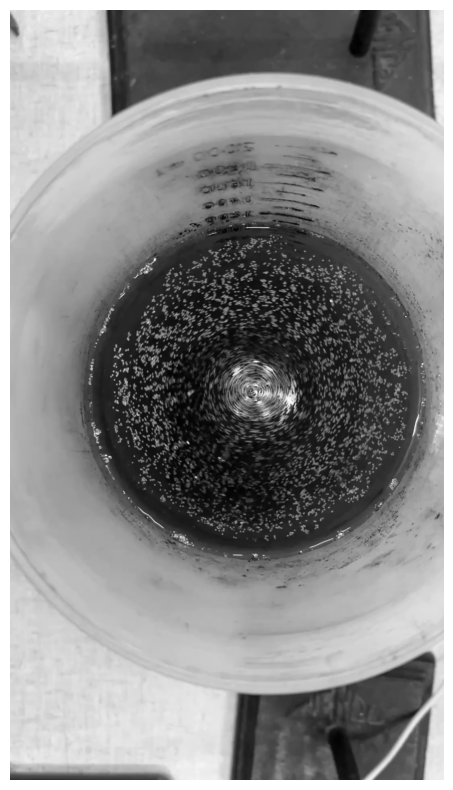

In [4]:
frame1_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
frame2_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 10))

plt.imshow(frame1_gray, cmap="gray")
plt.axis("off")

plt.show()

In [5]:
# Escala solo para visualizar cómodamente
escala = 0.45

frame_preview = cv2.resize(
    frame1,
    None,
    fx=escala,
    fy=escala
)

roi_preview = cv2.selectROI(
    "Selecciona ROI",
    frame_preview,
    fromCenter=False,
    showCrosshair=True
)

cv2.destroyAllWindows()

# Coordenadas elegidas sobre la imagen reducida
xp, yp, wp, hp = roi_preview

# Las convertimos a coordenadas de la imagen ORIGINAL
x0 = int(xp / escala)
y0 = int(yp / escala)
w  = int(wp / escala)
h  = int(hp / escala)

print("ROI en imagen original:")
print("x =", x0)
print("y =", y0)
print("ancho =", w)
print("alto =", h)

ROI en imagen original:
x = 204
y = 562
ancho = 817
alto = 808


(808, 817)


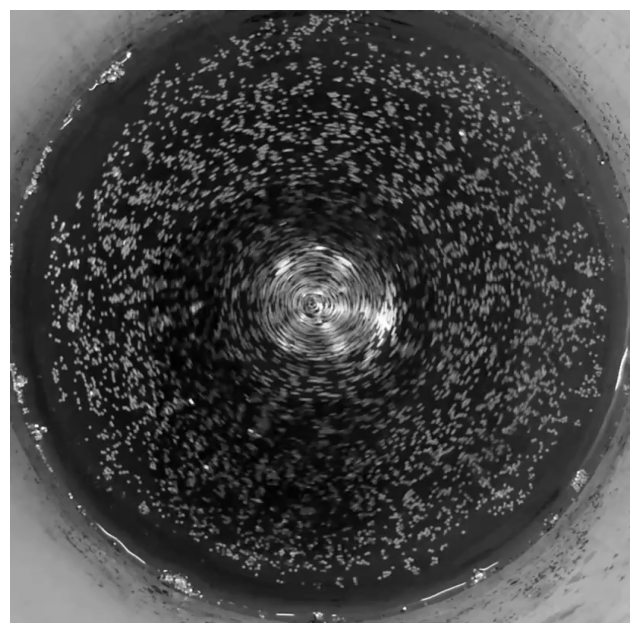

In [8]:
frame1_roi = frame1_gray[y0:y0+h, x0:x0+w]
frame2_roi = frame2_gray[y0:y0+h, x0:x0+w]

print(frame1_roi.shape)
plt.figure(figsize=(8, 8))
plt.imshow(frame1_roi, cmap="gray")
plt.axis("off")
plt.show()

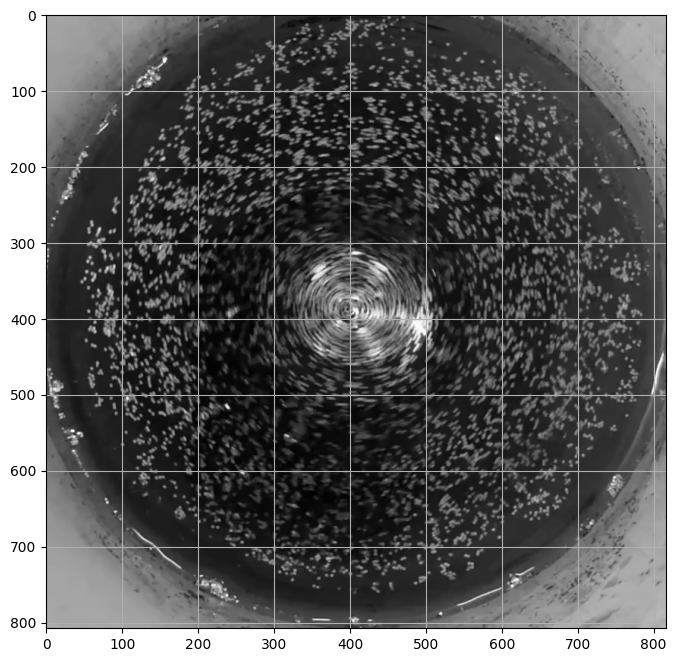

In [10]:
plt.figure(figsize=(8, 8))
plt.imshow(frame1_roi, cmap="gray")
plt.grid()
plt.show()

In [15]:
puntos = []

imagen_click = cv2.cvtColor(frame1_roi, cv2.COLOR_GRAY2BGR)

def elegir_puntos(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        puntos.append((x, y))

        cv2.circle(
            imagen_click,
            (x, y),
            5,
            (0, 0, 255),
            -1
        )

cv2.namedWindow("Centro y borde")
cv2.setMouseCallback("Centro y borde", elegir_puntos)

print("1er click: centro del recipiente")
print("2do click: borde interior del líquido")

while len(puntos) < 2:
    cv2.imshow("Centro y borde", imagen_click)

    if cv2.waitKey(20) & 0xFF == 27:
        break

cv2.destroyAllWindows()

print(puntos)

1er click: centro del recipiente
2do click: borde interior del líquido
[(397, 390), (715, 104)]


In [16]:
(cx, cy) = puntos[0]
(xb, yb) = puntos[1]

radio = np.sqrt(
    (xb - cx)**2 +
    (yb - cy)**2
)

print("Centro:", cx, cy)
print("Radio:", radio)

Centro: 397 390
Radio: 427.69147758635546


In [17]:
Y, X = np.ogrid[
    :frame1_roi.shape[0],
    :frame1_roi.shape[1]
]

mask = (X - cx)**2 + (Y - cy)**2 > radio**2

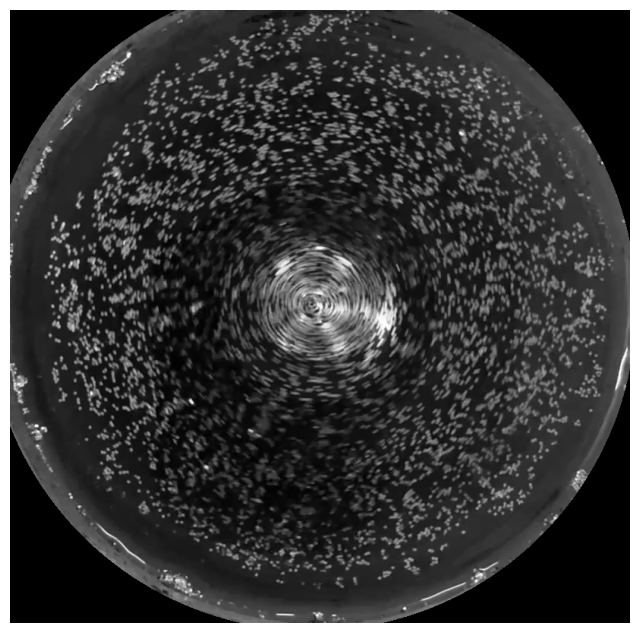

In [18]:
prueba = frame1_roi.copy()

prueba[mask] = 0

plt.figure(figsize=(8, 8))
plt.imshow(prueba, cmap="gray")
plt.axis("off")
plt.show()

In [31]:
from openpiv import pyprocess

dt = 1 / fps

window1 = 96
step1 = 48
overlap1 = window1 - step1

u1, v1, s2n1 = pyprocess.extended_search_area_piv(
    frame1_roi,
    frame2_roi,
    window_size=window1,
    overlap=overlap1,
    dt=dt,
    search_area_size=window1,
    correlation_method="circular",
    subpixel_method="gaussian",
    sig2noise_method="peak2peak"
)

x1, y1 = pyprocess.get_coordinates(
    image_size=frame1_roi.shape,
    search_area_size=window1,
    overlap=overlap1
)

print("Forma del campo:", u1.shape)

Forma del campo: (15, 16)


In [32]:
xi = np.rint(x1).astype(int)
yi = np.rint(y1).astype(int)

xi = np.clip(xi, 0, mask.shape[1] - 1)
yi = np.clip(yi, 0, mask.shape[0] - 1)

mask_vectores1 = mask[yi, xi]

u1_plot = np.ma.array(u1, mask=mask_vectores1)
v1_plot = np.ma.array(v1, mask=mask_vectores1)

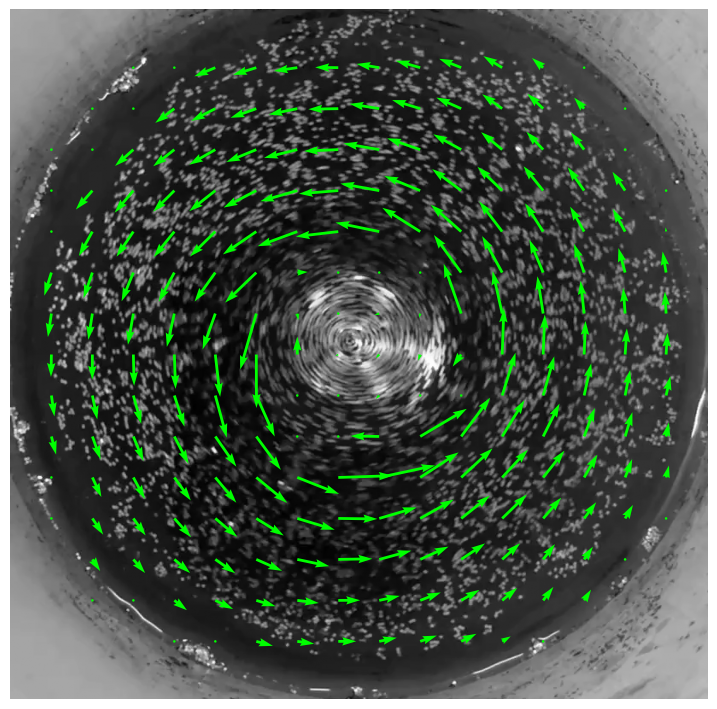

In [33]:
plt.figure(figsize=(9, 9))

plt.imshow(frame1_roi, cmap="gray")

plt.quiver(
    x1,
    y1,
    u1_plot,
    v1_plot,
    color="lime",
    angles="xy",
    width=0.004
)

plt.axis("off")
plt.show()

In [34]:
from openpiv import windef

settings = windef.PIVSettings()

# Pass 1: 96 px, step 48
# Pass 2: 64 px, step 32
settings.windowsizes = (96, 64)
settings.overlap = (48, 32)
settings.num_iterations = 2

settings.correlation_method = "circular"
settings.subpixel_method = "gaussian"

# Esto es lo importante: deformación usando el campo anterior
settings.deformation_method = "symmetric"

# Nuestra máscara
settings.static_mask = mask

# Por ahora no quiero que el filtrado sea demasiado agresivo
settings.sig2noise_validate = False
settings.min_max_u_disp = (-100, 100)
settings.min_max_v_disp = (-100, 100)
settings.std_threshold = 20
settings.median_threshold = 10

In [35]:
f1 = frame1_roi.astype(np.int32)
f2 = frame2_roi.astype(np.int32)

x1_m, y1_m, du1, dv1, s2n1 = windef.first_pass(
    f1,
    f2,
    settings
)

print(du1.shape)

(15, 16)


In [36]:
xi1 = np.rint(x1_m).astype(int)
yi1 = np.rint(y1_m).astype(int)

xi1 = np.clip(xi1, 0, mask.shape[1] - 1)
yi1 = np.clip(yi1, 0, mask.shape[0] - 1)

mask1 = mask[yi1, xi1]

du1 = np.ma.array(du1, mask=mask1)
dv1 = np.ma.array(dv1, mask=mask1)

In [37]:
x2, y2, du2, dv2, mask2, flags2 = windef.multipass_img_deform(
    f1,
    f2,
    1,          # índice del segundo pass
    x1_m,
    y1_m,
    du1,
    dv1,
    settings
)

(24, 24) (24, 24) (24, 24)


In [38]:
dt = 1 / fps

u2 = du2 / dt
v2 = dv2 / dt

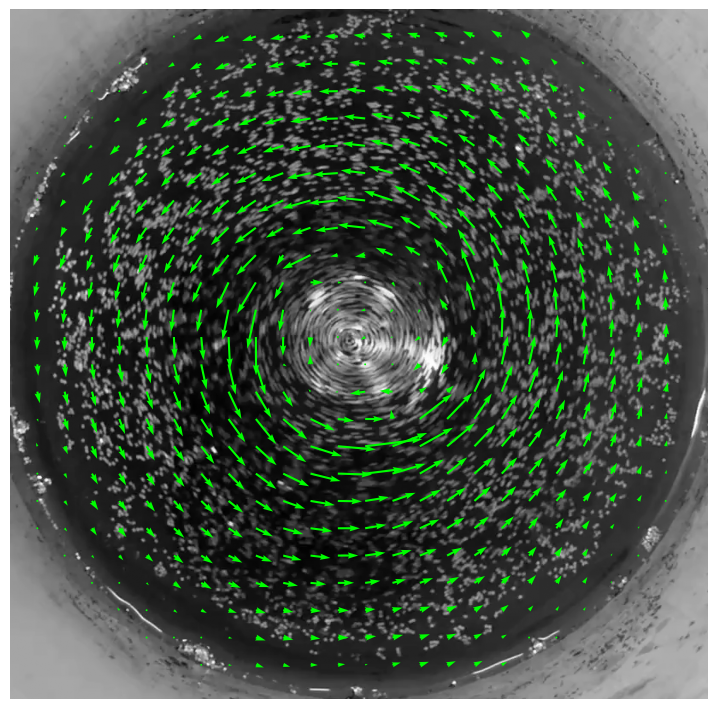

In [39]:
plt.figure(figsize=(9, 9))

plt.imshow(frame1_roi, cmap="gray")

plt.quiver(
    x2,
    y2,
    u2,
    v2,
    color="lime",
    angles="xy",
    width=0.003
)

plt.xlim(0, frame1_roi.shape[1])
plt.ylim(frame1_roi.shape[0], 0)

plt.axis("off")
plt.show()

Calibramos

In [41]:
distancia_real_mm = 147
distancia_px = 1514

mm_por_px = distancia_real_mm / distancia_px

print("Escala:", mm_por_px, "mm/px")

dt = 1 / fps

print("dt:", dt, "s")

Escala: 0.09709379128137384 mm/px
dt: 0.016686746987951806 s


In [42]:
u2_mm_s = du2 * mm_por_px / dt
v2_mm_s = dv2 * mm_por_px / dt

In [43]:
import numpy as np
from scipy.ndimage import generic_filter

# Pasamos a arrays normales; las zonas enmascaradas quedan como NaN
du = np.asarray(np.ma.filled(du2, np.nan), dtype=float)
dv = np.asarray(np.ma.filled(dv2, np.nan), dtype=float)

# Máscara geométrica del recipiente
mask_geom = np.asarray(mask2, dtype=bool)

validos_iniciales = (
    ~mask_geom
    & np.isfinite(du)
    & np.isfinite(dv)
)

In [44]:
n_std = 8

mean_u = np.nanmean(np.where(validos_iniciales, du, np.nan))
mean_v = np.nanmean(np.where(validos_iniciales, dv, np.nan))

std_u = np.nanstd(np.where(validos_iniciales, du, np.nan))
std_v = np.nanstd(np.where(validos_iniciales, dv, np.nan))

bad_std = (
    (du < mean_u - n_std * std_u)
    | (du > mean_u + n_std * std_u)
    | (dv < mean_v - n_std * std_v)
    | (dv > mean_v + n_std * std_v)
)

In [45]:
def filtro_mediana_nan(a, size=5):
    return generic_filter(
        a,
        np.nanmedian,
        size=size,
        mode="nearest"
    )

In [46]:
du_valid = np.where(validos_iniciales, du, np.nan)
dv_valid = np.where(validos_iniciales, dv, np.nan)

med_u = filtro_mediana_nan(du_valid, size=5)
med_v = filtro_mediana_nan(dv_valid, size=5)

In [55]:
med_u = filtro_mediana_nan(du_valid, size=3)
med_v = filtro_mediana_nan(dv_valid, size=3)

res_u = np.abs(du - med_u)
res_v = np.abs(dv - med_v)

med_res_u = filtro_mediana_nan(
    np.where(validos_iniciales, res_u, np.nan),
    size=3
)

med_res_v = filtro_mediana_nan(
    np.where(validos_iniciales, res_v, np.nan),
    size=3
)

In [73]:
epsilon = 0.1
umbral_mediana = 6

norm_u = res_u / (med_res_u + epsilon)
norm_v = res_v / (med_res_v + epsilon)

residuo_normalizado = np.sqrt(
    norm_u**2 + norm_v**2
)

bad_mediana = residuo_normalizado > umbral_mediana

In [74]:
rechazados = (
    validos_iniciales
    & (bad_std | bad_mediana)
)

validos_finales = (
    validos_iniciales
    & ~rechazados
)

In [75]:
n_inicial = np.sum(validos_iniciales)
n_rechazados = np.sum(rechazados)
n_final = np.sum(validos_finales)

print("Vectores iniciales:", n_inicial)
print("Rechazados:", n_rechazados)
print("Vectores finales:", n_final)

print(
    "Porcentaje rechazado:",
    100 * n_rechazados / n_inicial,
    "%"
)

Vectores iniciales: 518
Rechazados: 21
Vectores finales: 497
Porcentaje rechazado: 4.054054054054054 %


In [76]:
u_valid = np.ma.masked_where(~validos_finales, u2)
v_valid = np.ma.masked_where(~validos_finales, v2)

u_bad = np.ma.masked_where(~rechazados, u2)
v_bad = np.ma.masked_where(~rechazados, v2)

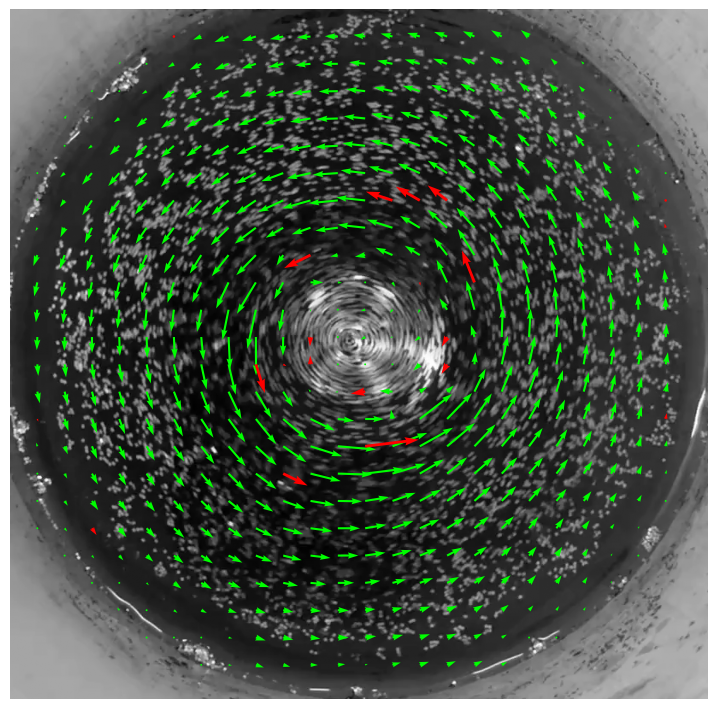

In [77]:
plt.figure(figsize=(9, 9))

plt.imshow(frame1_roi, cmap="gray")

# Vectores aceptados
plt.quiver(
    x2,
    y2,
    u_valid,
    v_valid,
    color="lime",
    angles="xy",
    width=0.003
)

# Vectores rechazados
plt.quiver(
    x2,
    y2,
    u_bad,
    v_bad,
    color="red",
    angles="xy",
    width=0.004
)

plt.xlim(0, frame1_roi.shape[1])
plt.ylim(frame1_roi.shape[0], 0)

plt.axis("off")
plt.show()

In [80]:
from openpiv import filters

du_interp, dv_interp = filters.replace_outliers(
    du2,
    dv2,
    flags=rechazados,
    method="localmean",
    max_iter=3,
    kernel_size=1
)

In [81]:
du_interp = np.ma.array(du_interp, mask=mask2)
dv_interp = np.ma.array(dv_interp, mask=mask2)

In [82]:
distancia_real_mm = 147
distancia_px = 1514

mm_por_px = distancia_real_mm / distancia_px

u_mm_s = du_interp * mm_por_px * fps
v_mm_s = dv_interp * mm_por_px * fps

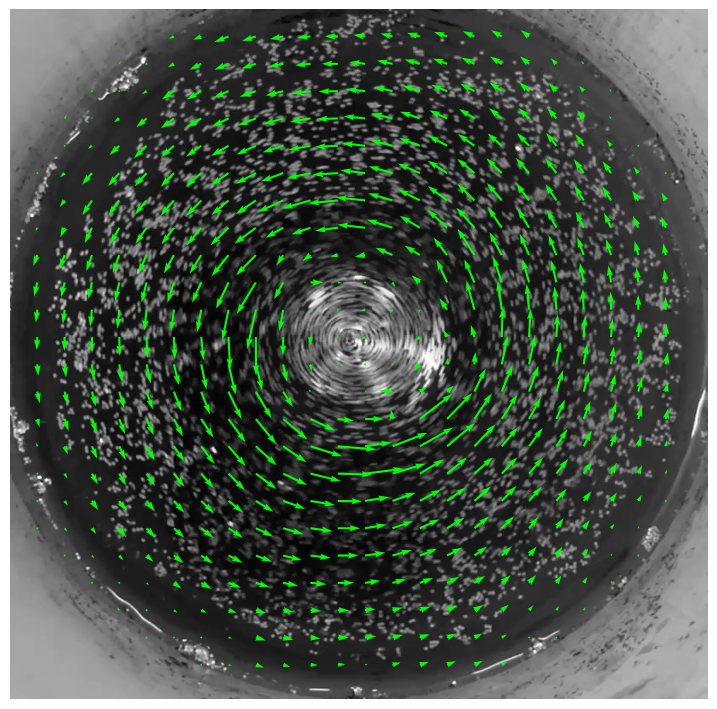

In [83]:
plt.figure(figsize=(9, 9))

plt.imshow(frame1_roi, cmap="gray")

plt.quiver(
    x2,
    y2,
    u_mm_s,
    v_mm_s,
    color="lime",
    angles="xy",
    width=0.003
)

plt.xlim(0, frame1_roi.shape[1])
plt.ylim(frame1_roi.shape[0], 0)

plt.axis("off")
plt.show()